In [1]:
import math
from itertools import combinations

class SearchService:
    def __init__(self, drone_locations: dict[str, tuple[float, float]], search_area: list[tuple[float, float]]):
        self.drone_locations = drone_locations
        self.routes = {}

        drone_ids = list(drone_locations.keys())
        k = len(drone_ids)
        n = len(search_area)

        # --- STEP 1: Define exact capacities ---
        base = n // k
        remainder = n % k
        capacities = [base + (1 if i < remainder else 0) for i in range(k)]

        # --- STEP 2: Balanced assignment ---
        clusters = {i: [] for i in range(k)}
        remaining_capacity = capacities[:]

        # Sort points: assign difficult (far) points first
        points = sorted(
            search_area,
            key=lambda p: min(self._distance(p, drone_locations[d]) for d in drone_ids),
            reverse=True
        )

        def cost(i, point):
            start = drone_locations[drone_ids[i]]
            base_dist = self._distance(point, start)
            spread_penalty = len(clusters[i]) * 0.2  # tune this
            return base_dist + spread_penalty

        for point in points:
            candidates = [i for i in range(k) if remaining_capacity[i] > 0]
            best_i = min(candidates, key=lambda i: cost(i, point))

            clusters[best_i].append(point)
            remaining_capacity[best_i] -= 1

        # --- STEP 3: Local swap optimization ---
        self._improve_clusters(clusters, drone_ids)

        # --- STEP 4: Build routes ---
        for i, drone_id in enumerate(drone_ids):
            start = drone_locations[drone_id]
            route = self._nearest_neighbor_route(start, clusters[i])

            # Improve route
            route = self._two_opt(route)

            route.append(start)
            self.routes[drone_id] = route

    # ------------------ HELPERS ------------------

    def _distance(self, a, b):
        return math.hypot(a[0] - b[0], a[1] - b[1])

    def _nearest_neighbor_route(self, start, points):
        points = points[:]
        route = [start]
        current = start

        while points:
            next_point = min(points, key=lambda p: self._distance(current, p))
            route.append(next_point)
            points.remove(next_point)
            current = next_point

        return route

    # --- 2-opt route optimization ---
    def _two_opt(self, route):
        best = route
        improved = True

        while improved:
            improved = False
            for i in range(1, len(best) - 2):
                for j in range(i + 1, len(best)):
                    if j - i == 1:
                        continue
                    new_route = best[:]
                    new_route[i:j] = reversed(best[i:j])

                    if self._route_length(new_route) < self._route_length(best):
                        best = new_route
                        improved = True
            route = best

        return best

    def _route_length(self, route):
        return sum(self._distance(route[i], route[i+1]) for i in range(len(route)-1))

    # --- Cluster improvement via swaps ---
    def _improve_clusters(self, clusters, drone_ids):
        improved = True

        while improved:
            improved = False

            for i, j in combinations(clusters.keys(), 2):
                for p1 in clusters[i]:
                    for p2 in clusters[j]:
                        d_i = self.drone_locations[drone_ids[i]]
                        d_j = self.drone_locations[drone_ids[j]]

                        old = (
                            self._distance(p1, d_i) +
                            self._distance(p2, d_j)
                        )
                        new = (
                            self._distance(p1, d_j) +
                            self._distance(p2, d_i)
                        )

                        if new < old:
                            clusters[i].remove(p1)
                            clusters[j].remove(p2)
                            clusters[i].append(p2)
                            clusters[j].append(p1)
                            improved = True
                            break
                    if improved:
                        break
                if improved:
                    break

In [4]:
import matplotlib.pyplot as plt
import random

def plot_drone_routes(search_service: SearchService):
    plt.figure(figsize=(8, 8))

    for drone_id, route in search_service.routes.items():
        print(len(route))

        if not route:
            continue

        xs = [p[0] for p in route]
        ys = [p[1] for p in route]

        color = (random.random(), random.random(), random.random())

        # Plot path
        plt.plot(xs, ys, marker='o', label=f"Drone {drone_id}", color=color)

        # Highlight start/end
        start = route[0]
        plt.scatter(start[0], start[1], color=color, s=100, edgecolors='black', zorder=3)

        # Optional: label start
        plt.text(start[0], start[1], f" {drone_id}", fontsize=9)

    plt.title("Drone Search Routes")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

8
8


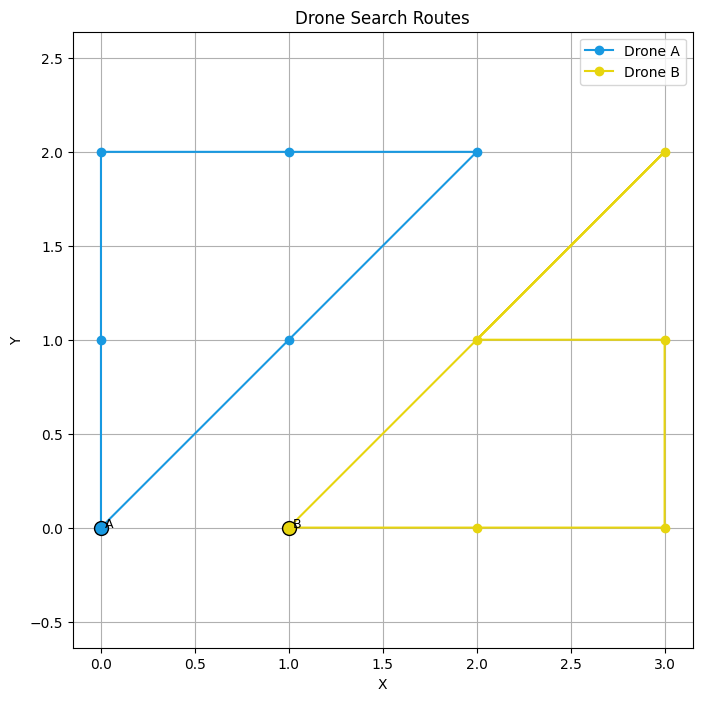

In [5]:
drones = {
    "A": (0, 0),
    "B": (1, 0),
}

search_area = [(x,y) for x in range(4) for y in range(3)]

service = SearchService(drones, search_area)
plot_drone_routes(service)